In [3]:
import pandas as pd

In [10]:
tmdb =pd.read_csv('C:/Users/hp/Documents/Data Analysis Professional/Python/tmdb.csv')

In [14]:
tmdb = tmdb.drop_duplicates()  # drop duplicates

In [15]:
essential_cols = ['id', 'imdb_id', 'original_title', 'release_date', 'budget', 'revenue']
tmdb = tmdb.dropna(subset=essential_cols) # drop rows with missing essential fields

In [16]:
text_cols = ['cast', 'director', 'tagline', 'keywords', 'overview', 'genres', 'production_companies']
tmdb[text_cols] = tmdb[text_cols].fillna('Unknown') # Fill missing values in textual fields

In [17]:
tmdb['release_date'] = pd.to_datetime(tmdb['release_date'], errors='coerce')
tmdb = tmdb.dropna(subset=['release_date']) # Convert release_date to datetime

In [18]:
tmdb['genres'] = tmdb['genres'].apply(lambda x: x.split('|') if isinstance(x, str) else [])
tmdb['cast'] = tmdb['cast'].apply(lambda x: x.split('|') if isinstance(x, str) else [])  # Convert 'cast' and 'genres' from pipe-separated strings to lists

In [19]:
tmdb = tmdb.drop(columns=['homepage']) # Drop low-utility columns

In [24]:
tmdb['release_year'] = tmdb['release_date'].dt.year
tmdb['profit'] = tmdb['revenue'] - tmdb['budget']

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [26]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6) #Set visual style

# 1. Top 10 most common Genres

C:\Users\hp\AppData\Local\Temp\ipykernel_23304\3447040932.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genres_df, x='Count', y='Genre', palette='viridis')


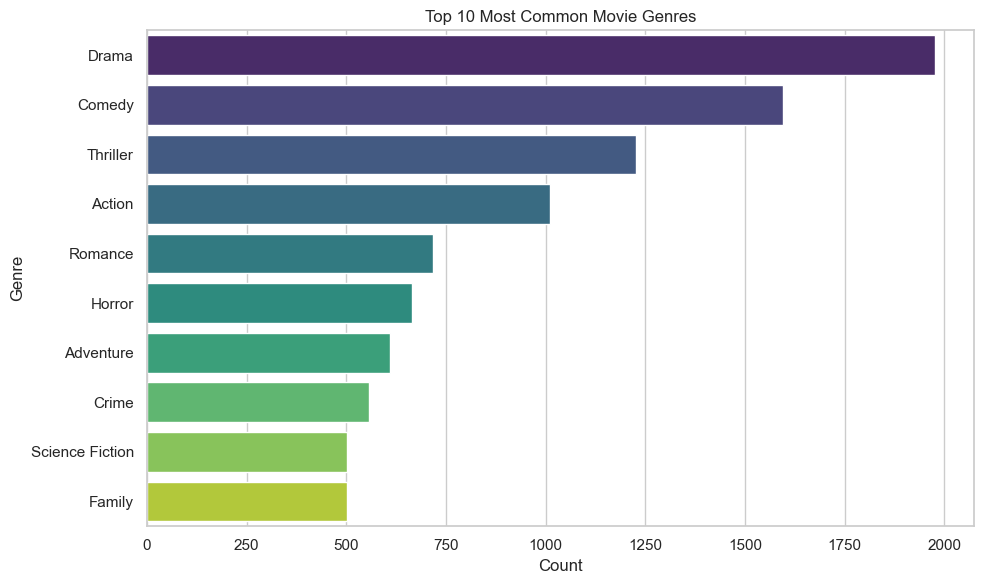

In [27]:
genre_counter = Counter()
tmdb['genres'].apply(lambda genres: genre_counter.update(genres))
genres_df = pd.DataFrame(genre_counter.most_common(10), columns=["Genre", "Count"])

sns.barplot(data=genres_df, x='Count', y='Genre', palette='viridis')
plt.title("Top 10 Most Common Movie Genres")
plt.tight_layout()
plt.show()

# 2. Top 10 Movies by Revenue

In [2]:
top_revenue = tmdb.sort_values(by='revenue', ascending=False).head(10)

sns.barplot(data=top_revenue, y='original_title', x='revenue', palette='magma')
plt.title("Top 10 Movies by Revenue")
plt.savefig('revenue_chart.png')
plt.tight_layout()
plt.show()

NameError: name 'tmdb' is not defined

# 3. Number of Movies Released per Year

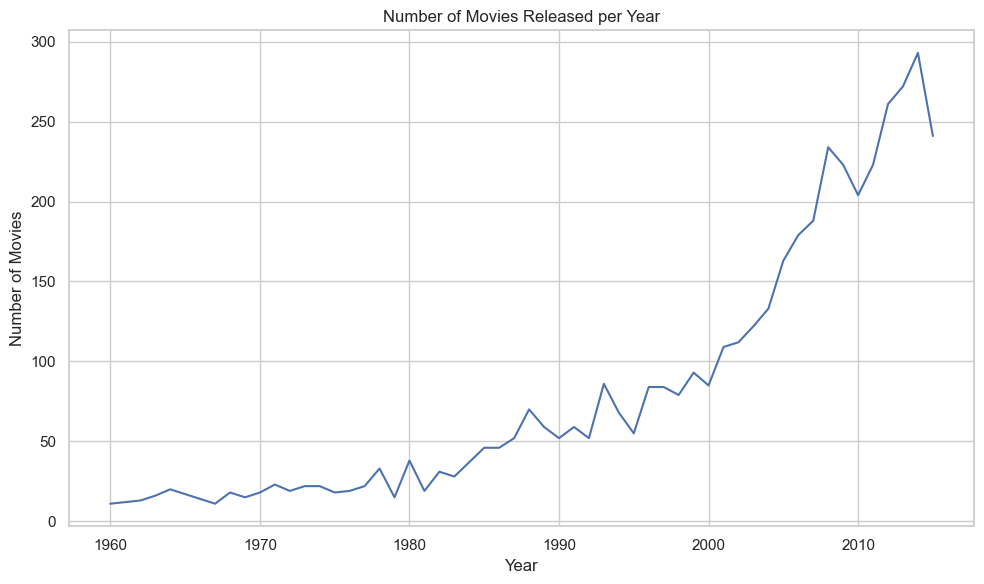

In [30]:
movies_per_year = tmdb['release_year'].value_counts().sort_index()

sns.lineplot(x=movies_per_year.index, y=movies_per_year.values)
plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

# 4.Top 10 Average Ratings by Genre

C:\Users\hp\AppData\Local\Temp\ipykernel_23304\2385208730.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_rating_per_genre, x='Rating', y=avg_rating_per_genre.index, palette='coolwarm')


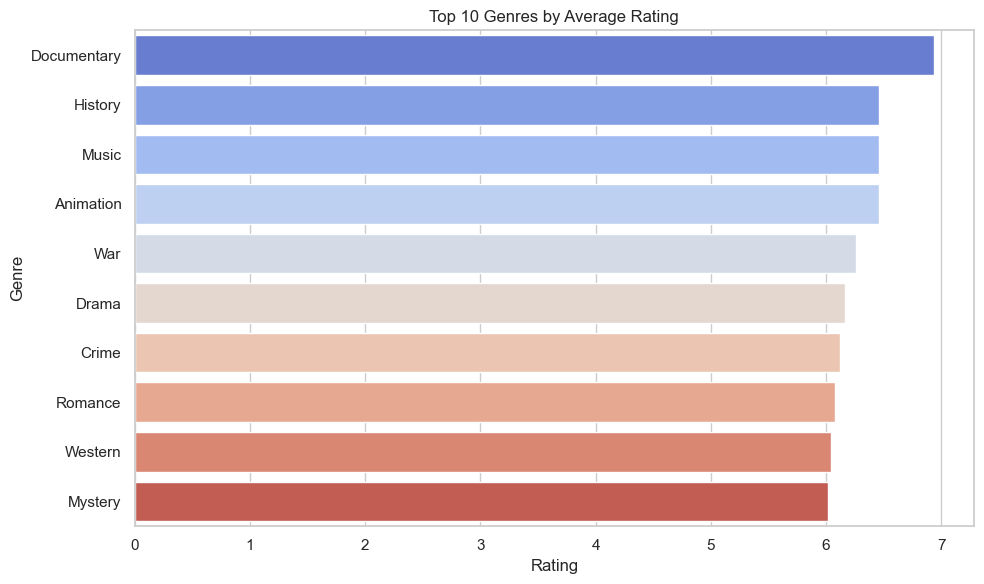

In [31]:
genre_ratings = []
for _, row in tmdb.iterrows():
    for genre in row['genres']:
        genre_ratings.append({'Genre': genre, 'Rating': row['vote_average']})

avg_rating_per_genre = pd.DataFrame(genre_ratings).groupby('Genre').mean().sort_values(by='Rating', ascending=False).head(10)

sns.barplot(data=avg_rating_per_genre, x='Rating', y=avg_rating_per_genre.index, palette='coolwarm')
plt.title("Top 10 Genres by Average Rating")
plt.tight_layout()
plt.show()

# 5. Top 10 Most Frequent Directors

C:\Users\hp\AppData\Local\Temp\ipykernel_23304\892877368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='cubehelix')


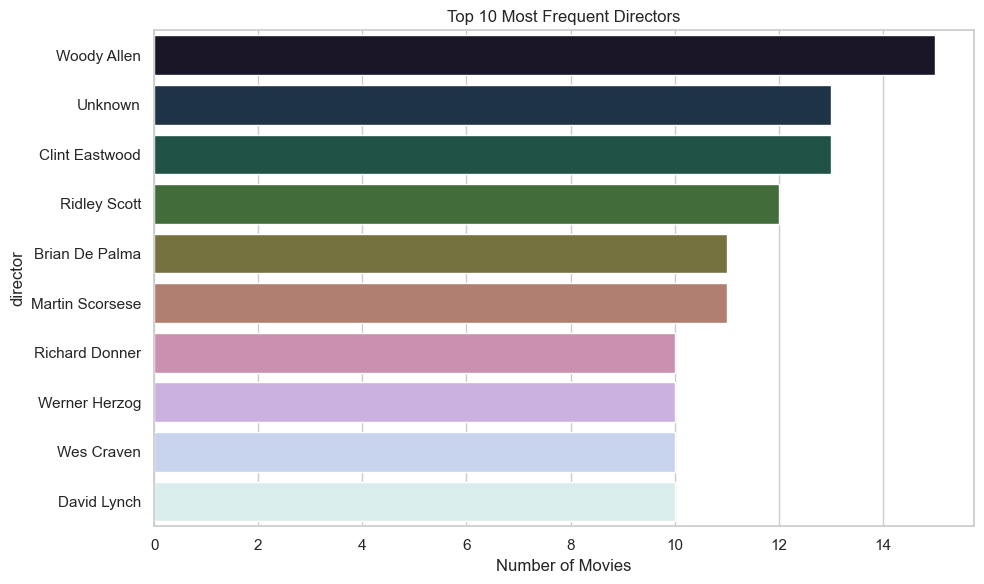

In [32]:
top_directors = tmdb['director'].value_counts().head(10)

sns.barplot(x=top_directors.values, y=top_directors.index, palette='cubehelix')
plt.title("Top 10 Most Frequent Directors")
plt.xlabel("Number of Movies")
plt.tight_layout()
plt.show()

# 6. Top 10 Most Frequently Appearing Actors

C:\Users\hp\AppData\Local\Temp\ipykernel_23304\796205924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=actors_df, x='Count', y='Actor', palette='Set2')


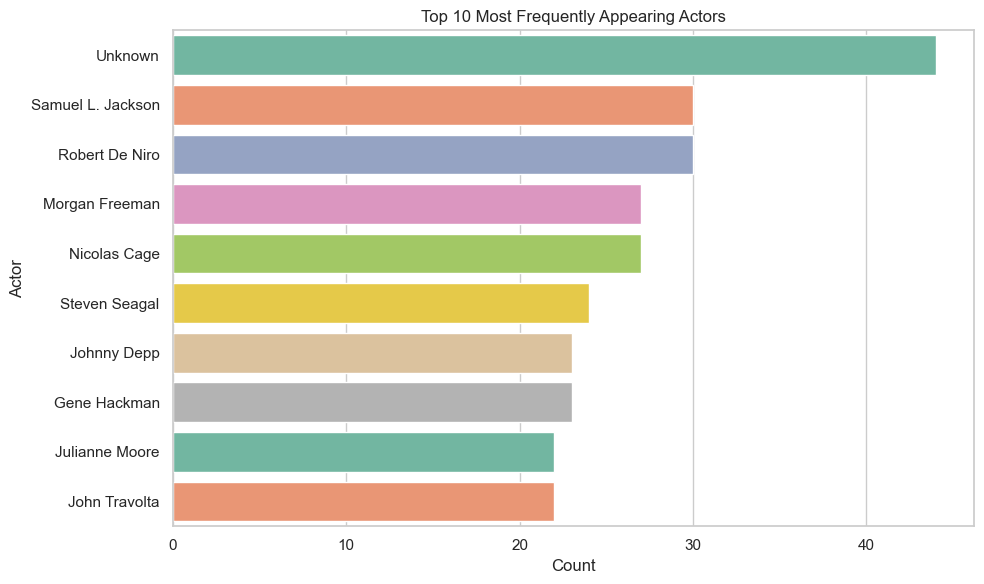

In [33]:
actor_counter = Counter()
tmdb['cast'].apply(lambda cast: actor_counter.update(cast))
actors_df = pd.DataFrame(actor_counter.most_common(10), columns=["Actor", "Count"])

sns.barplot(data=actors_df, x='Count', y='Actor', palette='Set2')
plt.title("Top 10 Most Frequently Appearing Actors")
plt.tight_layout()
plt.show()

# 7. Top 10 Most Profitable Movies

C:\Users\hp\AppData\Local\Temp\ipykernel_23304\2311364476.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_profit, x='profit', y='original_title', palette='YlGnBu')


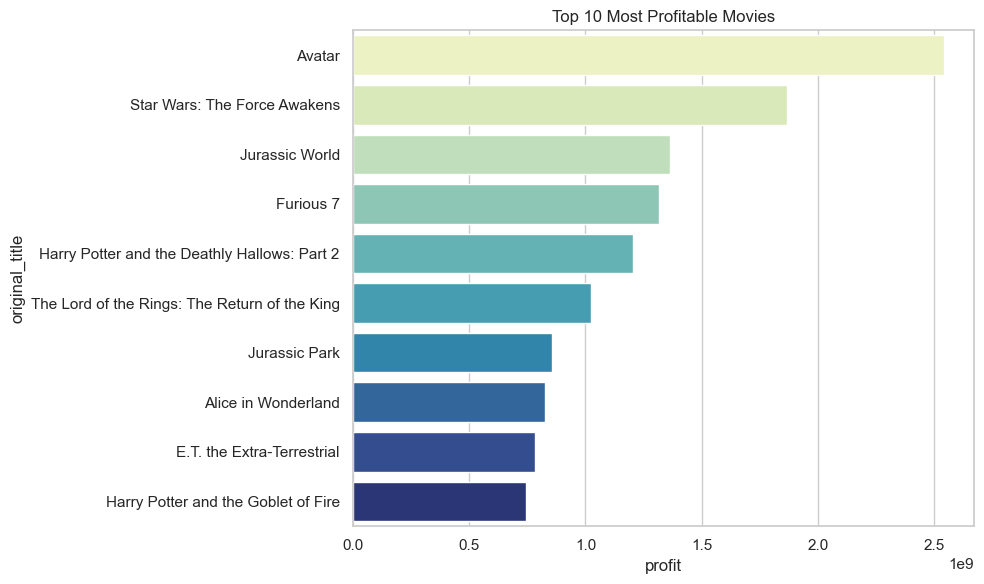

In [34]:
top_profit = tmdb.sort_values(by='profit', ascending=False).head(10)

sns.barplot(data=top_profit, x='profit', y='original_title', palette='YlGnBu')
plt.title("Top 10 Most Profitable Movies")
plt.tight_layout()
plt.show()

# 8. Average Runtime Over the Years

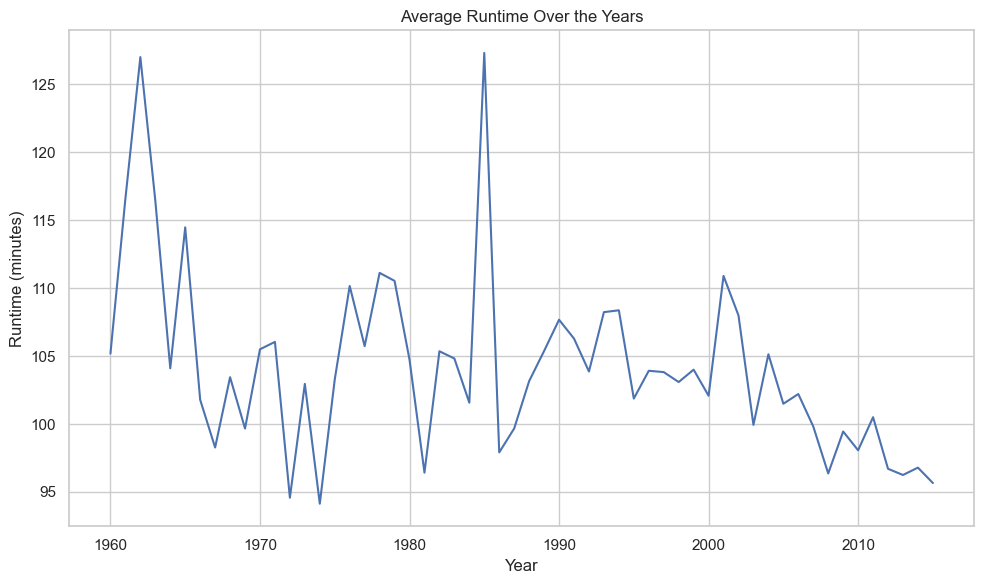

In [35]:
avg_runtime_per_year = tmdb.groupby('release_year')['runtime'].mean().dropna()

sns.lineplot(x=avg_runtime_per_year.index, y=avg_runtime_per_year.values)
plt.title("Average Runtime Over the Years")
plt.xlabel("Year")
plt.ylabel("Runtime (minutes)")
plt.tight_layout()
plt.show()

# 9.Distribution of Movie Ratings

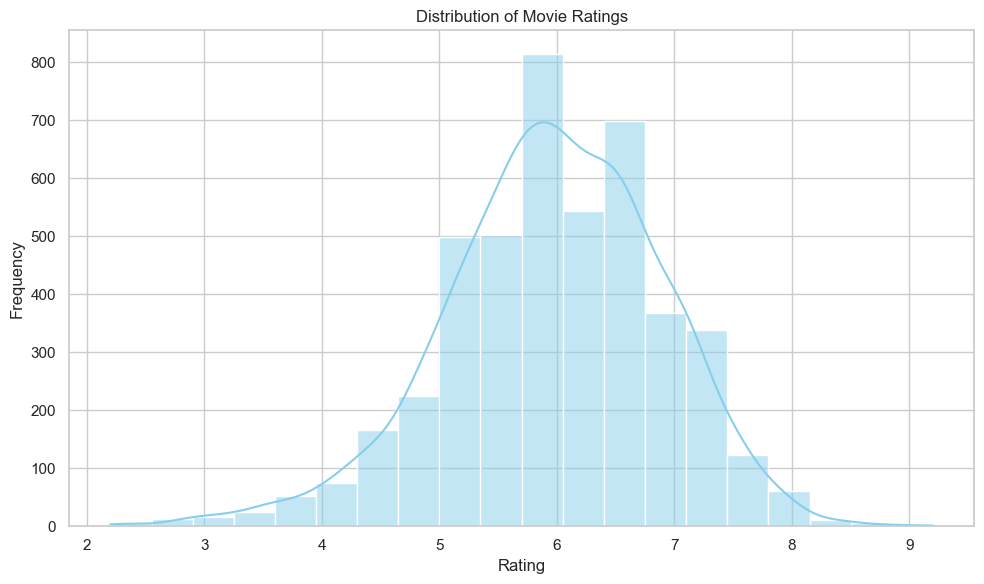

In [36]:
sns.histplot(data=tmdb['vote_average'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()